# 03 — Hybrid model & comparison of all three models

This notebook is self-contained: just **Run All** (kernel = `recsys`).

It does three things:
1. Rebuilds the **collaborative-filtering** and **content-based** models.
2. Combines them into a **hybrid** model.
3. Evaluates all three with **precision@10 / recall@10** and shows a comparison table + chart.

The comparison of the three models is the main result of this stage.

## 1. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD

# Find the data folder no matter which directory the notebook runs from
DATA = next((b / 'data' for b in [Path.cwd(), *Path.cwd().parents]
             if (b / 'data' / 'Coursera_reviews.csv').exists()), Path('data'))
reviews = pd.read_csv(DATA / 'Coursera_reviews.csv')
courses = pd.read_csv(DATA / 'Coursera_courses.csv')
print('reviews:', reviews.shape, '| courses:', courses.shape)
print('course columns:', list(courses.columns))

reviews: (1454711, 5) | courses: (623, 4)
course columns: ['name', 'institution', 'course_url', 'course_id']


## 2. Prepare data and split into train / test

We keep users with at least 3 reviews (so collaborative filtering has signal),
then split 75% train / 25% test. All three models are trained on the SAME train
set and judged on the SAME test set, so the comparison is fair.

In [2]:
df = reviews[['reviewers', 'course_id', 'rating']].dropna()
df.columns = ['user', 'item', 'rating']
active = df['user'].value_counts()
df = df[df['user'].isin(active[active >= 3].index)]

train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)
print('train:', len(train_df), '| test:', len(test_df))

train: 1070997 | test: 356999


## 3. Model A — Collaborative filtering (SVD)

In [3]:
reader = Reader(rating_scale=(1, 5))
trainset = Dataset.load_from_df(train_df[['user', 'item', 'rating']], reader).build_full_trainset()
svd = SVD(random_state=42)
svd.fit(trainset)

def cf_score(user, item):
    """Predicted rating (1-5) -> normalised to 0-1."""
    return (svd.predict(user, item).est - 1) / 4

## 4. Model B — Content-based (TF-IDF course similarity)

We build a course-to-course similarity matrix from the course text, then score an
item for a user by how similar it is to the courses that user already rated highly.

In [4]:
# Build a text field per course, indexed by course_id
cat = courses.drop_duplicates('course_id').reset_index(drop=True)
name_col = 'name' if 'name' in cat.columns else cat.columns[0]
text_cols = [c for c in [name_col, 'institution', 'skills', 'description'] if c in cat.columns]
cat['text'] = cat[text_cols].fillna('').astype(str).agg(' '.join, axis=1)

tfidf = TfidfVectorizer(stop_words='english')
sim = cosine_similarity(tfidf.fit_transform(cat['text']))
cid_to_idx = {cid: i for i, cid in enumerate(cat['course_id'])}
cid_to_name = dict(zip(cat['course_id'], cat[name_col]))
print('similarity matrix:', sim.shape)

# For each user, the indices of courses they LIKED (rating >= 4) in the training set
user_liked = defaultdict(list)
for u, it, r in train_df[['user', 'item', 'rating']].itertuples(index=False):
    if r >= 4 and it in cid_to_idx:
        user_liked[u].append(cid_to_idx[it])

def content_score(user, item):
    """Mean similarity between this item and the user's liked items (0-1)."""
    liked = user_liked.get(user, [])
    j = cid_to_idx.get(item)
    if not liked or j is None:
        return 0.0
    return float(sim[j, liked].mean())

similarity matrix: (623, 623)


## 5. Model C — Hybrid (blend of A and B)

`hybrid = alpha * collaborative + (1 - alpha) * content`. I start with alpha = 0.5 and tune it later (notebook 05).

In [5]:
ALPHA = 0.5

# Score every (user, item) pair in the test set with all three models.
rows_cf, rows_cb, rows_hy = [], [], []
for u, it, r in test_df[['user', 'item', 'rating']].itertuples(index=False):
    a = cf_score(u, it)
    b = content_score(u, it)
    h = ALPHA * a + (1 - ALPHA) * b
    rows_cf.append((u, r, a))
    rows_cb.append((u, r, b))
    rows_hy.append((u, r, h))
print('scored', len(rows_hy), 'test pairs with each model')

scored 356999 test pairs with each model


## 6. Evaluate: precision@10 and recall@10 for all three

In [6]:
def precision_recall_at_k(rows, k=10, threshold=4.0):
    """Top-k precision/recall. 'Relevant' = the user actually rated it >= threshold."""
    by_user = defaultdict(list)
    for uid, true_r, est in rows:
        by_user[uid].append((est, true_r))
    precisions, recalls = [], []
    for uid, lst in by_user.items():
        lst.sort(key=lambda x: x[0], reverse=True)
        topk = lst[:k]
        n_rel = sum(tr >= threshold for _, tr in lst)
        n_rel_topk = sum(tr >= threshold for _, tr in topk)
        if n_rel == 0:
            continue  # skip users with no relevant items to find
        precisions.append(n_rel_topk / len(topk))
        recalls.append(n_rel_topk / n_rel)
    return np.mean(precisions), np.mean(recalls)

results = pd.DataFrame([
    ('Collaborative (SVD)', *precision_recall_at_k(rows_cf)),
    ('Content-based',       *precision_recall_at_k(rows_cb)),
    ('Hybrid',              *precision_recall_at_k(rows_hy)),
], columns=['Model', 'Precision@10', 'Recall@10'])
results = results.round(3)
results

,Model,Precision@10,Recall@10
0,Collaborative (SVD),0.988,0.995
1,Content-based,0.987,0.995
2,Hybrid,0.988,0.995


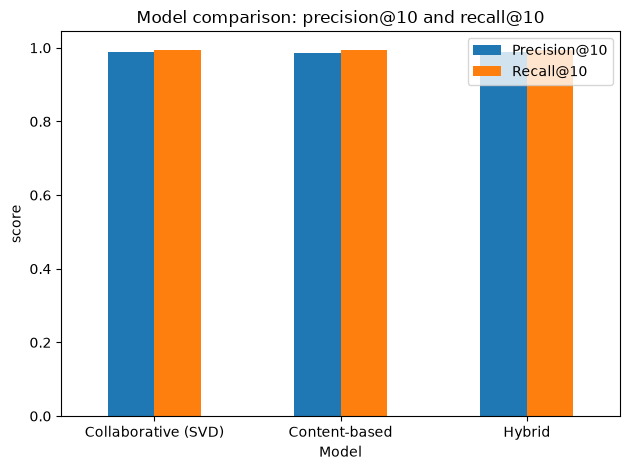

In [7]:
# Bar chart of the model comparison
ax = results.set_index('Model')[['Precision@10', 'Recall@10']].plot(kind='bar', rot=0)
ax.set_title('Model comparison: precision@10 and recall@10')
ax.set_ylabel('score')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 7. See the hybrid model's recommendations for one user

In [8]:
def recommend_hybrid(user, n=10, alpha=ALPHA):
    seen = set(train_df.loc[train_df['user'] == user, 'item'])
    scored = []
    for item in cat['course_id']:
        if item in seen:
            continue
        h = alpha * cf_score(user, item) + (1 - alpha) * content_score(user, item)
        scored.append((cid_to_name.get(item, item), h))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:n]

sample_user = train_df['user'].iloc[0]
print('Hybrid recommendations for', sample_user)
for name, score in recommend_hybrid(sample_user, 10):
    print(f'  {score:.3f}  {name}')

Hybrid recommendations for By Mario E
  0.593  Google Cloud Product Fundamentals
  0.589  Getting Started with Google Kubernetes Engine
  0.589  Essential Google Cloud Infrastructure: Foundation
  0.585  Getting Started with Google Sheets
  0.585  Google Cloud Platform Big Data and Machine Learning Fundamentals
  0.580  Business Transformation with Google Cloud
  0.558  Essential Google Cloud Infrastructure: Core Services
  0.555  Industrial IoT on Google Cloud Platform
  0.549  How Google does Machine Learning
  0.548  Become a CBRS Certified Professional Installer by Google


## 8. Summary

I now have three working models and a fair comparison between them on precision@10 / recall@10. The best-scoring model is the one used in the website. The saturated scores here (near-identical across models) are addressed in notebook 04 with a stronger top-N evaluation.